# Principal Component Analysis (PCA)

This notebook builds up **Principal Component Analysis (PCA)** step by step: first on toy 2D examples to develop the geometric intuition, and then on a multidimensional `xarray.Dataset` using `bluemath_tk`, covering data preparation, model fitting, dimensionality reduction, reconstruction, diagnostics, persistence, and visualization of the Empirical Orthogonal Functions (EOFs).

> **Objective:** summarize a multidimensional dataset with a small number of components while retaining as much of its original variability as possible.

## Workflow

**Part I: intuition with 2D examples**

1. A perfectly correlated case ($x = y$).
2. A correlated 2D cloud of points (multivariate normal).

**Part II: PCA on a multidimensional dataset with `bluemath_tk`**

3. Load a sample `xarray.Dataset`.
4. Configure and fit the PCA model.
5. Transform the original fields into principal-component scores and reconstruct them.
6. Inspect the model diagnostics.
7. Save the fitted model and plot its leading EOFs.

In [2]:
import logging
import warnings
warnings.filterwarnings("ignore")

# Hide bluemath_tk PCA log messages below ERROR (they are still available by removing this line)
logging.getLogger("PCA").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from bluemath_tk.core.data.sample_data import get_2d_dataset
from bluemath_tk.datamining.pca import PCA

# Part I: building intuition in 2D

PCA rotates the original feature space onto orthogonal directions of decreasing variance. If $\mathbf{X}$ is the centered data matrix (observations × features), PCA decomposes it as

$$\mathbf{X} \approx \mathbf{P}\mathbf{E}^{T},$$

where $\mathbf{P}$ contains the principal-component scores and $\mathbf{E}$ contains the EOFs (spatial patterns or loadings).

With only two features, the EOFs are simply two perpendicular directions in the $(x, y)$ plane, so we can draw them on top of the data.

The `bluemath_tk` PCA works on `xarray.Dataset` objects, so the 2D samples are stored in a single variable `values` with dimensions `sample` (the observations, i.e. the PCA rows) and `feature` (`x` and `y`, the columns that get stacked). In these examples `scale_data=False` is used so that PCA works on the raw $(x, y)$ values and the EOFs can be drawn directly in the original plane.

The helpers below build that dataset from a NumPy array and plot the samples together with each component as an arrow starting at the data mean, with a length of one standard deviation along that component ($\sqrt{\text{explained variance}}$).

In [3]:
def to_dataset(data):
    return xr.Dataset(
        {"values": (("sample", "feature"), data)},
        coords={"sample": np.arange(data.shape[0]), "feature": ["x", "y"]},
    )


def plot_pca_2d(data, pca_model, title=None):
    fig, ax = plt.subplots(figsize=(6, 6), tight_layout=True)
    ax.scatter(data[:, 0], data[:, 1], s=40, alpha=0.3, label="samples")

    mean = data.mean(axis=0)
    eofs = pca_model.eofs["values"].values  # [n_component, feature]

    for n in range(eofs.shape[0]):
        vector = eofs[n] * np.sqrt(pca_model.explained_variance[n])
        ax.annotate(
            "",
            xy=mean + vector,
            xytext=mean,
            arrowprops=dict(arrowstyle="->", linewidth=4, color=f"C{n + 2}"),
        )
        ax.plot(
            [], [], linewidth=4, color=f"C{n + 2}",
            label=f"PC{n + 1} (EV ratio = {pca_model.explained_variance_ratio[n]:.2f})",
        )

    ax.set(aspect="equal", xlabel="x (first feature)", ylabel="y (second feature)", title=title)
    ax.legend()
    return ax

## 1. Perfectly correlated variables: $x = y$

When the two features are identical, all the points lie on a single line. There is only **one** direction with variability, so the first component should capture 100% of the variance and the second one nothing.

In [4]:
x = np.linspace(2, 4, 100)
y = x

matrix_pca = np.vstack([x, y]).T
matrix_pca.shape  # [Number of points] x [Number of dimensions]

(100, 2)

In [5]:
ds_xy = to_dataset(matrix_pca)
ds_xy

<xarray.Dataset> Size: 2kB
Dimensions:  (sample: 100, feature: 2)
Coordinates:
  * sample   (sample) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * feature  (feature) <U1 8B 'x' 'y'
Data variables:
    values   (sample, feature) float64 2kB 2.0 2.0 2.02 2.02 ... 3.98 4.0 4.0

In [6]:
pca_xy = PCA(n_components=2)
pca_xy.fit(
    data=ds_xy,
    vars_to_stack=["values"],
    coords_to_stack=["feature"],
    pca_dim_for_rows="sample",
    scale_data=False,
)

print("EOFs (rows):\n", pca_xy.eofs["values"].values)
print("Explained variance ratio:", pca_xy.explained_variance_ratio.round(4))

2026-09-23 12:38:07,651 - PCA - WARNING - Using 2 out of 2 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:07,652 - PCA - WARNING - Data is not standarized


EOFs (rows):
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]
Explained variance ratio: [1. 0.]


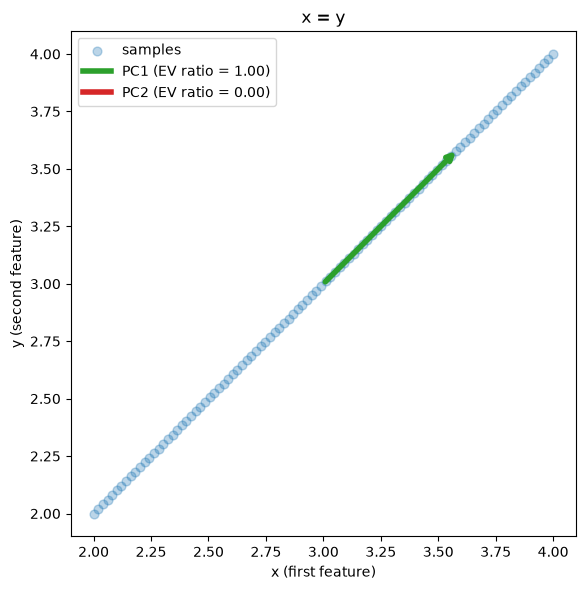

In [7]:
plot_pca_2d(matrix_pca, pca_xy, title="x = y");

The first EOF is $(1/\sqrt{2}, 1/\sqrt{2})$, i.e. the direction of the line $x = y$, and it explains all the variance. A single number per observation (its PC1 score) is enough to describe the data: we have reduced two dimensions to one without losing information.

## 2. 2D variability: correlated random variables

Real data are rarely perfectly correlated. Here we draw samples from a **multivariate normal** distribution whose covariance matrix introduces a positive correlation between $x$ and $y$:

$$\Sigma = \begin{pmatrix} 3 & 3 \\ 3 & 4 \end{pmatrix}$$

In [8]:
# Random matrix with correlation between the different variables
rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)

ds_2d = to_dataset(X)
ds_2d

<xarray.Dataset> Size: 12kB
Dimensions:  (sample: 500, feature: 2)
Coordinates:
  * sample   (sample) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
  * feature  (feature) <U1 8B 'x' 'y'
Data variables:
    values   (sample, feature) float64 8kB -3.123 -3.267 -2.776 ... 2.082 2.083

In [9]:
pca_2d = PCA(n_components=2)
pca_2d.fit(
    data=ds_2d,
    vars_to_stack=["values"],
    coords_to_stack=["feature"],
    pca_dim_for_rows="sample",
    scale_data=False,
)

print("EOFs (rows):\n", pca_2d.eofs["values"].values)
print("Explained variance ratio:", pca_2d.explained_variance_ratio.round(4))

2026-09-23 12:38:07,941 - PCA - WARNING - Using 2 out of 2 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:07,942 - PCA - WARNING - Data is not standarized


EOFs (rows):
 [[ 0.64402153  0.76500736]
 [ 0.76500736 -0.64402153]]
Explained variance ratio: [0.9311 0.0689]


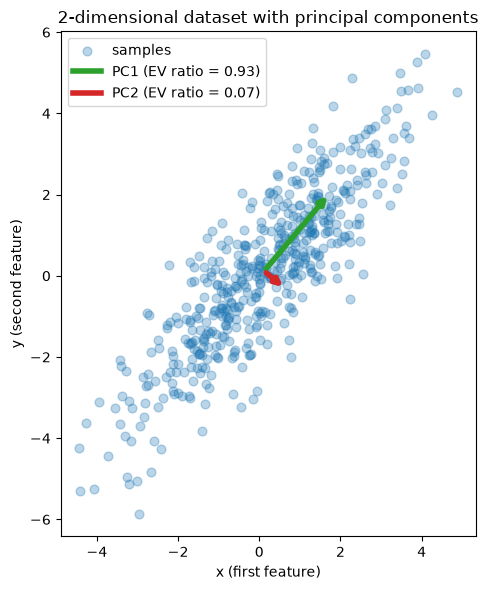

In [10]:
plot_pca_2d(X, pca_2d, title="2-dimensional dataset with principal components");

Now both components carry some variance, but the first one, aligned with the main axis of the cloud, explains most of it. The second component is perpendicular to the first and captures the remaining spread.

Projecting the data onto the EOFs gives the **PC scores**. In this new coordinate system the two variables are uncorrelated: PCA is just a rotation of the original axes.

2026-09-23 12:38:08,120 - PCA - WARNING - Using 2 out of 2 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:08,121 - PCA - WARNING - Data is not standarized


[None,
 Text(0.5, 0, 'PC1'),
 Text(0, 0.5, 'PC2'),
 Text(0.5, 1.0, 'PC space (corr = -0.00)')]

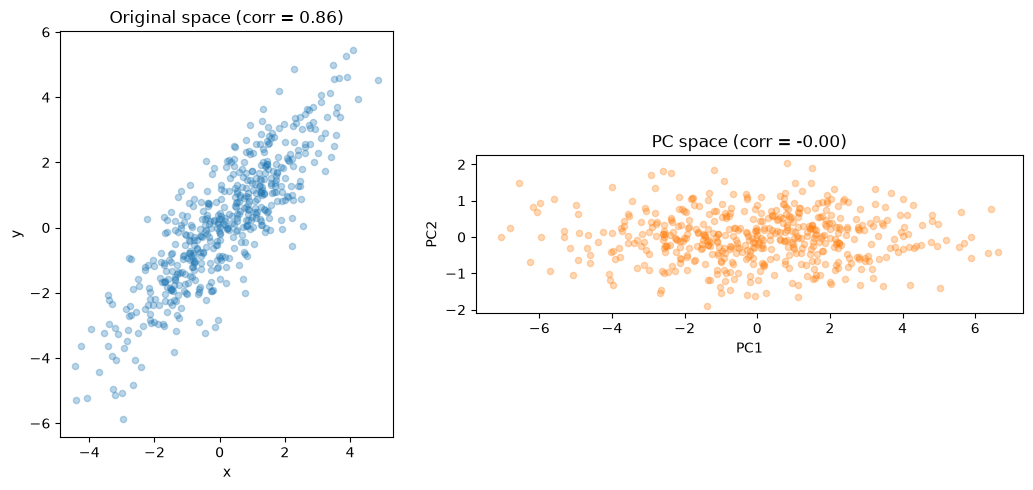

In [11]:
scores = pca_2d.transform(data=ds_2d)["PCs"].values

fig, axes = plt.subplots(1, 2, figsize=(11, 5), tight_layout=True)
axes[0].scatter(X[:, 0], X[:, 1], s=20, alpha=0.3)
axes[0].set(aspect="equal", xlabel="x", ylabel="y",
            title=f"Original space (corr = {np.corrcoef(X.T)[0, 1]:.2f})")
axes[1].scatter(scores[:, 0], scores[:, 1], s=20, alpha=0.3, color="C1")
axes[1].set(aspect="equal", xlabel="PC1", ylabel="PC2",
            title=f"PC space (corr = {np.corrcoef(scores.T)[0, 1]:.2f})")

Keeping only PC1 would retain most of the variability with half the dimensions. The same idea scales to datasets with thousands of features (e.g. every grid point of a field), which is where PCA becomes really useful.

# Part II: PCA on a multidimensional dataset with `bluemath_tk`

## 3. Load the sample dataset

The helper function returns an `xarray.Dataset` containing the variables `X` and `Y`. Inspecting the dataset first is useful for confirming its variables, coordinates, dimensions, and missing values before stacking it for PCA.

In [12]:
ds = get_2d_dataset()
ds

<xarray.Dataset> Size: 314kB
Dimensions:  (coord1: 20, coord2: 20, coord3: 49)
Coordinates:
  * coord1   (coord1) float64 160B -100.0 -89.47 -78.95 ... 78.95 89.47 100.0
  * coord2   (coord2) float64 160B -100.0 -89.47 -78.95 ... 78.95 89.47 100.0
  * coord3   (coord3) int64 392B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49
Data variables:
    X        (coord1, coord2, coord3) float64 157kB -0.08724 0.2777 ... -0.2849
    Y        (coord1, coord2, coord3) float64 157kB 0.08713 -0.2742 ... 0.2811

Each variable is a **3D block** of data: for every value of `coord3` (think of it as time) there is a full 2D map over `coord1` × `coord2` (think of them as space, a 20 × 20 grid). A single map is just one slice of that block:

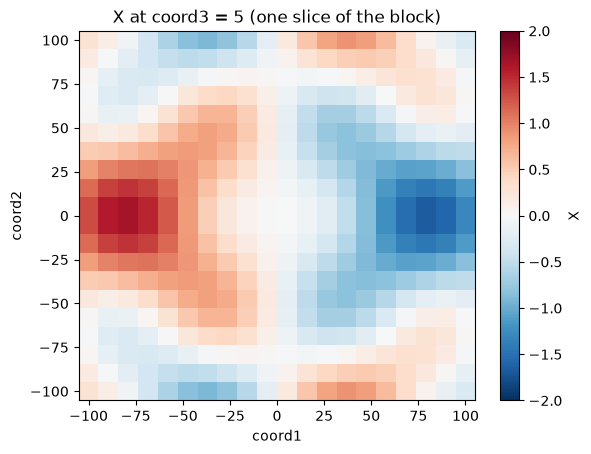

In [13]:
ds.X.sel(coord3=5).plot(x="coord1", y="coord2", cmap="RdBu_r", vmin=-2, vmax=2)
plt.title("X at coord3 = 5 (one slice of the block)");

Drawing several slices on top of each other shows the whole structure: a stack of maps, one per `coord3` value, for each variable.

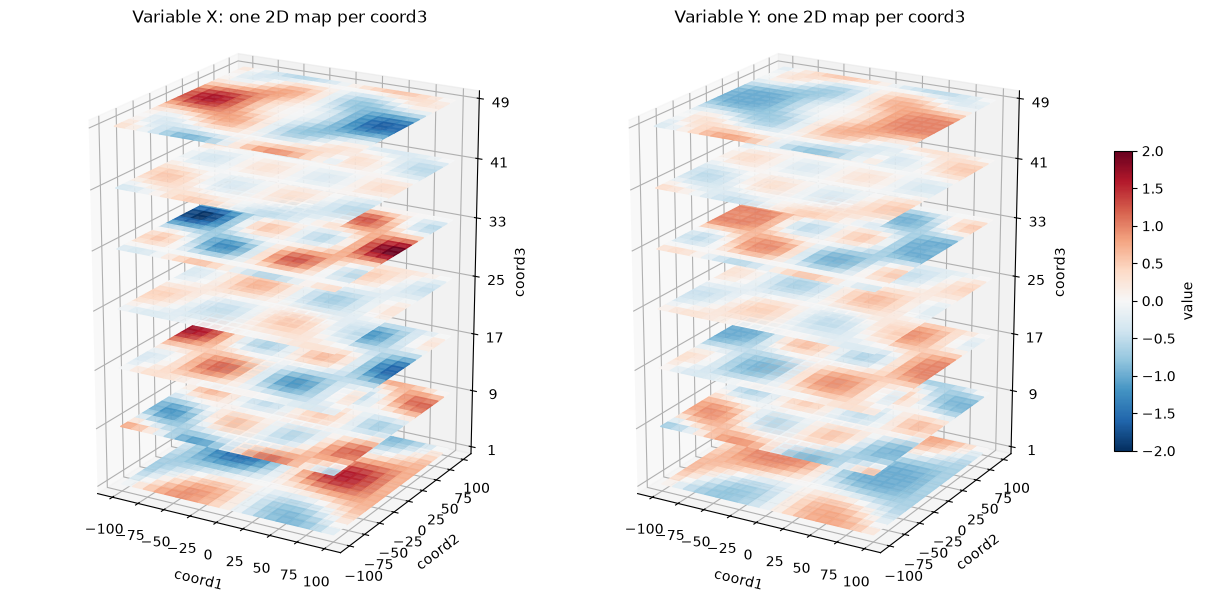

In [14]:
steps = ds.coord3.values[::8]
cmap, norm = plt.cm.RdBu_r, plt.Normalize(-2, 2)
C1, C2 = np.meshgrid(ds.coord1, ds.coord2, indexing="ij")

fig = plt.figure(figsize=(12, 6))
axes = []
for i, var in enumerate(["X", "Y"]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    for t in steps:
        field = ds[var].sel(coord3=t).values  # [coord1, coord2]
        ax.plot_surface(
            C1, C2, np.full_like(C1, t),
            facecolors=cmap(norm(field)), rstride=1, cstride=1, shade=False, alpha=0.9,
        )
    ax.set(xlabel="coord1", ylabel="coord2", zlabel="coord3", title=f"Variable {var}: one 2D map per coord3")
    ax.set_zticks(steps)
    ax.view_init(elev=20, azim=-60)
    ax.set_box_aspect((1, 1, 1.4))
    axes.append(ax)

fig.subplots_adjust(left=0, right=0.9, bottom=0, top=1, wspace=0)
cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, label="value");

PCA, however, needs a 2D matrix (observations × features). The trick is to **flatten each map into a row**: every `coord3` becomes one observation, and every grid point of every variable becomes one feature. With 2 variables on a 20 × 20 grid this gives 2 × 400 = 800 columns. This is exactly what the `coords_to_stack` and `pca_dim_for_rows` arguments of `fit` do below.

Compared with Part I, where each observation was a point with 2 features ($x$, $y$), each observation is now a whole pair of maps with 800 features.

PCA matrix shape [coord3 x (variables * grid points)]: (49, 800)


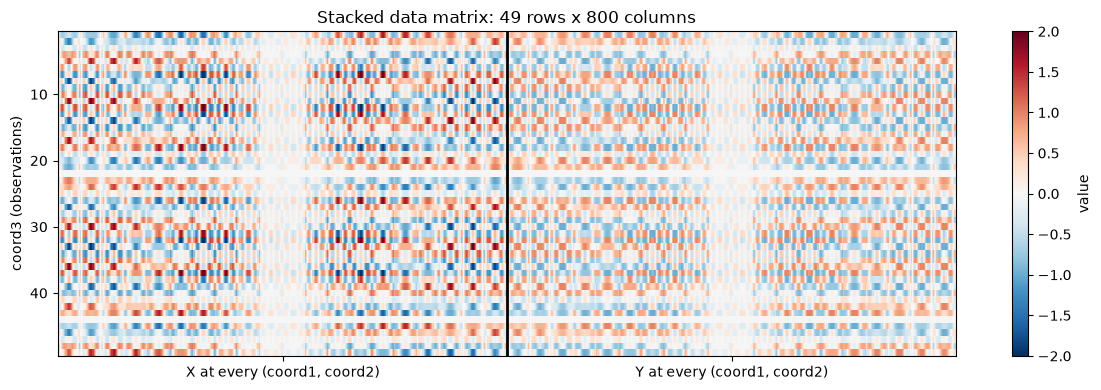

In [15]:
stacked = ds[["X", "Y"]].stack(positions=["coord1", "coord2"])  # [coord3, positions]
matrix = np.hstack([stacked["X"].values, stacked["Y"].values])
n_points = stacked.sizes["positions"]
print("PCA matrix shape [coord3 x (variables * grid points)]:", matrix.shape)

fig, ax = plt.subplots(figsize=(12, 4), tight_layout=True)
im = ax.imshow(
    matrix, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest",
    extent=[-0.5, matrix.shape[1] - 0.5, ds.coord3.values[-1] + 0.5, ds.coord3.values[0] - 0.5],
)
ax.axvline(n_points - 0.5, color="k", linewidth=2)
ax.set_xticks([n_points / 2, 1.5 * n_points], ["X at every (coord1, coord2)", "Y at every (coord1, coord2)"])
ax.set(ylabel="coord3 (observations)", title=f"Stacked data matrix: {matrix.shape[0]} rows x {matrix.shape[1]} columns")
fig.colorbar(im, ax=ax, label="value");

## 4. Configure the PCA model

Each observation now has many features (all the grid points of `X` and `Y`), so the EOFs are spatial patterns instead of 2D arrows, but the decomposition $\mathbf{X} \approx \mathbf{P}\mathbf{E}^{T}$ is exactly the same as in Part I.

The model retains five components. Standard PCA is used instead of incremental PCA, and debug logging is enabled to expose additional execution details.

### Constructor arguments

- `n_components`: amount of information retained. An integer such as `5` keeps exactly five components; a float can instead represent a desired cumulative explained-variance ratio.
- `is_incremental`: selects standard PCA (`False`) or incremental PCA (`True`). Incremental fitting is useful when the complete matrix is too large to process in memory at once.
- `debug`: enables more detailed diagnostic logging. It is helpful while learning or troubleshooting, but can be disabled for quieter production runs.

In [16]:
pca = PCA(
    n_components=5,
    is_incremental=False,
    debug=True,
)

## 5. Fit the model

The variables `X` and `Y` are combined into the feature matrix by stacking `coord1` and `coord2`; `coord3` defines the observations placed along the PCA row dimension.

The optional preprocessing settings demonstrate how to handle realistic data:

- `windows_in_pca_dim_for_rows` restricts `X` to the selected windows `[1, 2, 3]`.
- `value_to_replace_nans` replaces remaining missing values in `X` with `0.0`.
### Arguments used in `fit`

- `data`: input `xarray.Dataset` used to learn the PCA basis.
- `vars_to_stack`: dataset variables combined into one feature matrix. Here PCA learns the joint variability of `X` and `Y`.
- `coords_to_stack`: coordinates flattened into feature columns. In this example, every `coord1`–`coord2` location becomes a PCA feature.
- `pca_dim_for_rows`: dimension kept as observations or rows, commonly time. Here every `coord3` value becomes one observation.
- `windows_in_pca_dim_for_rows`: lag or rolling-window steps added for each variable. `X: [1, 2, 3]` incorporates three shifted versions of `X`. Use `{}` when no temporal windows are needed.
- `value_to_replace_nans`: replacement value per variable after preprocessing. `X: 0.0` fills remaining missing values in `X` with zero.
- `nan_threshold_to_drop`: valid-data threshold applied per variable. The value `0.95` requires approximately 95% valid values; features that do not meet it are excluded.
- `scale_data`: defaults to `True` and standardizes features so variables with larger units do not dominate the components. It is omitted here because the default is appropriate.

`fit` learns the EOFs and preprocessing metadata in place; it does not return the transformed PCs.

In [17]:
pca.fit(
    data=ds,
    vars_to_stack=["X", "Y"],
    coords_to_stack=["coord1", "coord2"],
    pca_dim_for_rows="coord3",
    windows_in_pca_dim_for_rows={"X": [1, 2, 3]},
    value_to_replace_nans={"X": 0.0},
    nan_threshold_to_drop={"X": 0.95},
)

2026-09-23 12:38:09,241 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:09,242 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:09,243 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:09,245 - PCA - WARNING - Data contains NaNs.
2026-09-23 12:38:09,248 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:09,248 - PCA - WARNING - Data contains NaNs.
2026-09-23 12:38:09,249 - PCA - WARNING - Using 0 out of 400 available variables 
If this is originated by using few times, plea

## 6. Transform and reconstruct the data

`transform(data=ds)` receives a dataset with the same variables and coordinate structure used during fitting and returns its principal-component scores. It uses the preprocessing configuration already stored in `pca`.

`inverse_transform(PCs=pcs)` receives those component scores through the case-sensitive `PCs` argument and maps them back to an `xarray.Dataset` in the original variable space. Because only five components are retained, the reconstruction is a compressed approximation rather than an exact copy.

In [18]:
pcs = pca.transform(data=ds)
pcs

2026-09-23 12:38:09,313 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:09,315 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:09,316 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:09,317 - PCA - WARNING - Data contains NaNs.
2026-09-23 12:38:09,323 - PCA - WARNING - Using 400 out of 400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-09-23 12:38:09,325 - PCA - WARNING - Data contains NaNs.
2026-09-23 12:38:09,326 - PCA - WARNING - Using 0 out of 400 available variables 
If this is originated by using few times, plea

<xarray.Dataset> Size: 2kB
Dimensions:      (coord3: 49, n_component: 5)
Coordinates:
  * coord3       (coord3) int64 392B 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * n_component  (n_component) int64 40B 0 1 2 3 4
Data variables:
    PCs          (coord3, n_component) float64 2kB -10.44 -25.48 ... 20.8 1.378
    stds         (n_component) float64 40B 23.47 19.81 16.57 13.96 13.16

In [19]:
reconstructed_ds = pca.inverse_transform(PCs=pcs)
reconstructed_ds

<xarray.Dataset> Size: 785kB
Dimensions:  (coord3: 49, coord1: 20, coord2: 20)
Coordinates:
  * coord3   (coord3) int64 392B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49
  * coord1   (coord1) float64 160B -100.0 -89.47 -78.95 ... 78.95 89.47 100.0
  * coord2   (coord2) float64 160B -100.0 -89.47 -78.95 ... 78.95 89.47 100.0
Data variables:
    X        (coord3, coord1, coord2) float64 157kB -0.0713 -0.2654 ... -0.2426
    Y        (coord3, coord1, coord2) float64 157kB 0.06605 0.2611 ... 0.2314
    X_1      (coord3, coord1, coord2) float64 157kB 0.1585 0.1327 ... 0.671
    X_2      (coord3, coord1, coord2) float64 157kB 0.1196 0.1238 ... -0.3274
    X_3      (coord3, coord1, coord2) float64 157kB nan nan nan ... nan nan nan

## 7. Inspect EOFs and explained variance

The main PCA diagnostics are:

- **EOFs:** orthogonal patterns that define the new coordinate system.
- **Explained variance:** variance represented by each component.
- **Explained-variance ratio:** fraction of total variance represented by each component.
- **Cumulative ratio:** total fraction retained by the first $k$ components.

A rapid plateau in the cumulative ratio indicates that a compact model captures most of the information.

In [20]:
eofs = pca.eofs
explained_variance = pca.explained_variance
explained_variance_ratio = pca.explained_variance_ratio
cumulative_explained_variance_ratio = (
    pca.cumulative_explained_variance_ratio
)

variance_summary = pd.DataFrame(
    {
        "Explained variance": explained_variance,
        "Explained variance ratio": explained_variance_ratio,
        "Cumulative ratio": cumulative_explained_variance_ratio,
    },
    index=[f"PC{i}" for i in range(1, len(explained_variance) + 1)],
)
variance_summary.style.format("{:.4f}").set_caption(
    "Variance retained by each principal component"
)

,Explained variance,Explained variance ratio,Cumulative ratio
PC1,562.3095,0.3443,0.3443
PC2,400.5751,0.2453,0.5895
PC3,280.4055,0.1717,0.7612
PC4,199.0373,0.1219,0.8831
PC5,176.7557,0.1082,0.9913


## 8. Save the fitted model

The complete fitted PCA object is serialized to a pickle file. This preserves the preprocessing metadata, EOFs, and fitted transformation so the same model can be reused later without fitting it again.

`save_model(path)` receives the destination filename. Here `pca_model.pkl` is created in the notebook's working directory and stores the complete fitted object, including preprocessing metadata and EOFs.

> Only load pickle files from trusted sources, because unpickling arbitrary files can execute code.

In [23]:
pca.save_model("outputs/pca_theory_2D_model.pkl")

## 9. Plot the leading EOFs

The first three EOFs are displayed for `X` and `Y`. These plots show the dominant patterns of variability learned from the dataset. The sign of an EOF is arbitrary; its spatial structure and its pairing with the corresponding principal-component score are what carry meaning.

- `vars_to_plot`: variables from the fitted dataset whose EOF patterns should be drawn.
- `num_eofs`: number of leading EOFs to display. The first three are used because they explain the largest successive fractions of variance.

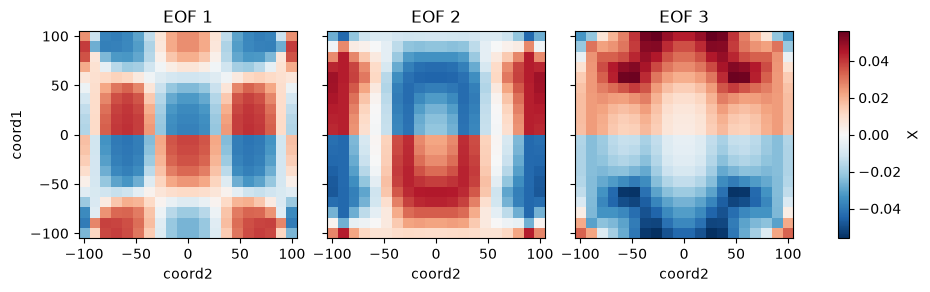

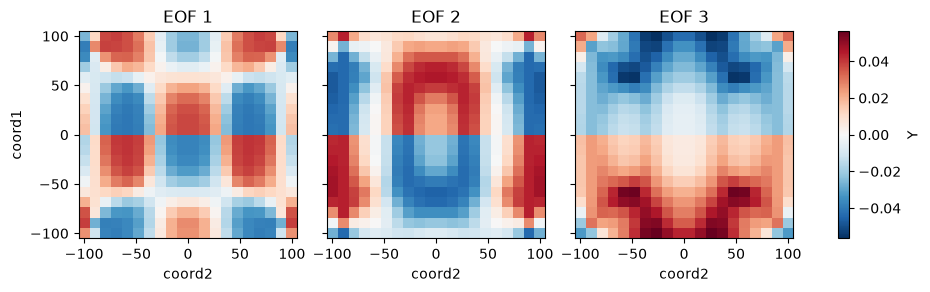

In [22]:
pca.plot_eofs(vars_to_plot=["X", "Y"], num_eofs=3)

## Summary

The 2D examples show what PCA does geometrically: it finds orthogonal directions ordered by the variance they explain, and rotates the data onto them. When the variables are strongly correlated, a few components are enough to describe most of the variability.

On the multidimensional dataset, the fitted model compresses the joint variability of `X` and `Y` into five components. The explained-variance diagnostics quantify the information retained, the inverse transformation reconstructs the original fields, and the EOF plots help interpret the dominant patterns.